[<img src="images/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/si-md2/blob/main/si-md2/notebooks_alunos/cap02/cap02_aluno.ipynb)
[<img src="images/github-badge.png" style="width:20%; vertical-align:middle;">](https://github.com/fzampirolli/si-md2)

# Mineração de Dados e Regras de Associação

## Introdução

A Mineração de Dados é uma disciplina tão vasta que qualquer publicação
sobre o tema obriga o autor a selecionar alguns tópicos em detrimento de
outros não menos importantes. A atividade de **Regras de Associação**
foi o tópico escolhido para iniciarmos a apresentação das principais
atividades da Mineração de Dados por envolver ideias bem intuitivas. A
analogia entre Regras de Associação e Cesta de Compras facilita o
entendimento de como descobrir padrões de associação entre itens de um
conjunto qualquer.

## Mineração de Dados

Durante o processo de **Descoberta de Conhecimento em Bases de Dados**,
**KDD**, é na etapa de **Mineração de Dados** que efetivamente são
encontrados os padrões de associação implícitos nos dados. A análise
automatizada dessa massa de dados visa detectar regularidades, ou quebra
de regularidade, que constitui informação implícita, porém desconhecida,
e útil para determinado fim.

A Mineração de Dados pode ser vista como a sistematização de teorias,
técnicas e algoritmos desenvolvidos em outras disciplinas já
consagradas, como a Estatística, a Inteligência Artificial, o
Aprendizado de Máquina, a Base de Dados etc. O propósito da Mineração de
Dados é detectar automaticamente padrões de associação úteis e não
óbvios em grandes quantidades de dados, veja [Figura 2.1](#fig-2-1).

No dia a dia, uma quantidade incalculável de dados é gerada na forma de
registros de vendas, textos brutos, imagens, sons, gráficos etc., tanto
por sistemas computacionais como por seres humanos, constituindo uma
espécie de informação não estruturada. Embora esta forma de registro de
dados seja adequada para o ser humano, quando se trata de analisar
grandes quantidades de dados de forma automatizada, é comum e
conveniente que se introduza alguma **estrutura** que facilite o acesso
e o processamento sistemático.

<figure id="fig-2-1" style="text-align:center; margin:1em 0;">
  <img src="images/fig-2-1.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 2.1:</strong> A Relação da Mineração de Dados com Algumas Disciplinas Correlatas.</figcaption>
</figure>

Para que parte de toda essa informação não estruturada possa ser
utilizada na Mineração de Dados, geralmente é feita uma seleção e um
pré-processamento visando transformar dados brutos em coleções
estruturadas de dados. Em termos práticos, para nossas considerações
iniciais, a estrutura de representação de uma Base de Dados pode ser
semelhante a uma tabela de dados, sendo cada linha dessa tabela uma
**transação** ou um **exemplo**. Cada **transação** é composta por um ou
mais **itens** ou, visto de outra forma, cada **exemplo** é
caracterizado por seus **atributos**.

As Tabelas [2.1](#tbl-2-cestas), [2.2](#tbl-2-booleana) e [2.3](#tbl-2-tempo) ilustram formas de dados estruturados convenientes para a Mineração de Dados.

**Tabela 2.1:** Cestas de Compras.

In [54]:
# @title { display-mode: "form" }
import pandas as pd
from IPython.display import Markdown

dados = {
    'TID': [1, 2, 3, 4, 5],
    'Itens': [
        '{Arroz, Feijão, Óleo}',
        '{Queijo, Vinho}',
        '{Arroz, Feijão, Batata, Óleo}',
        '{Arroz, Água, Queijo, Vinho}',
        '{Arroz, Feijão, Batata, Óleo}'
    ]
}
df = pd.DataFrame(dados)

# Para garantir que o Quarto entenda como Markdown puro e o Colab mostre formatado:
Markdown(df.to_markdown(index=False, colalign=("center", "left")))

|  TID  | Itens                         |
|:-----:|:------------------------------|
|   1   | {Arroz, Feijão, Óleo}         |
|   2   | {Queijo, Vinho}               |
|   3   | {Arroz, Feijão, Batata, Óleo} |
|   4   | {Arroz, Água, Queijo, Vinho}  |
|   5   | {Arroz, Feijão, Batata, Óleo} |

Na [Tabela 2.1](#tbl-2-cestas) cada uma das Transações possui uma IDentificação (TID), e
seus itens representam artigos vendidos em um supermercado. Se a tabela
de itens for muito extensa, como costuma ser em casos reais, pode ser
ainda mais conveniente representar cada um de seus itens na forma de um
atributo associado a um valor booleano, como mostra a [Tabela 2.2](#tbl-2-booleana).


**Tabela 2.2:** Representação Booleana de Cestas de Compras.

In [55]:
# @title { display-mode: "form" }
import pandas as pd
from IPython.display import Markdown

dados_booleana = {
    'TID': [1, 2, 3, 4, 5],
    'Arroz': ['y', 'n', 'y', 'y', 'y'],
    'Feijão': ['y', 'n', 'y', 'n', 'y'],
    'Batata': ['n', 'n', 'y', 'n', 'y'],
    'Óleo': ['y', 'n', 'y', 'n', 'y'],
    'Água': ['n', 'n', 'n', 'y', 'n'],
    'Queijo': ['n', 'y', 'n', 'y', 'n'],
    'Vinho': ['n', 'y', 'n', 'y', 'n']
}
df_booleana = pd.DataFrame(dados_booleana)

Markdown(df_booleana.to_markdown(index=False, colalign=("center",) * len(df_booleana.columns)))

|  TID  |  Arroz  |  Feijão  |  Batata  |  Óleo  |  Água  |  Queijo  |  Vinho  |
|:-----:|:-------:|:--------:|:--------:|:------:|:------:|:--------:|:-------:|
|   1   |    y    |    y     |    n     |   y    |   n    |    n     |    n    |
|   2   |    n    |    n     |    n     |   n    |   n    |    y     |    y    |
|   3   |    y    |    y     |    y     |   y    |   n    |    n     |    n    |
|   4   |    y    |    n     |    n     |   n    |   y    |    y     |    y    |
|   5   |    y    |    y     |    y     |   y    |   n    |    n     |    n    |

Um exemplo clássico de uma Base de Dados usada em artigos sobre
Mineração de Dados é apresentada na [Tabela 2.3](#tbl-2-tempo) (Quinlan (1986) *apud*  Witten e Frank (2005)), composta por dados fictícios sobre as condições
de tempo para que ocorra ou não a partida de um esporte não
especificado. A tabela é composta por 14 exemplos (linhas), cada um com
cinco atributos (colunas): Dia, Temperatura, Umidade, Vento e Partida. A
tabela pode também ser interpretada de outra forma, como sendo composta
por quatro atributos (Dia, Temperatura, Umidade e Vento) e uma classe
(Partida), que representa o resultado da combinação dos quatro
atributos.

**Tabela 2.3:** Tabela do Tempo.

In [56]:
# @title { display-mode: "form" }
import pandas as pd
from IPython.display import Markdown

dados_tempo = {
    'Dia': ['Ensolarado', 'Ensolarado', 'Nublado', 'Chuvoso', 'Chuvoso', 'Chuvoso', 'Nublado', 'Ensolarado', 'Ensolarado', 'Chuvoso', 'Ensolarado', 'Nublado', 'Nublado', 'Chuvoso'],
    'Temperatura': ['Elevada', 'Elevada', 'Elevada', 'Amena', 'Baixa', 'Baixa', 'Baixa', 'Amena', 'Baixa', 'Amena', 'Amena', 'Amena', 'Elevada', 'Amena'],
    'Umidade': ['Alta', 'Alta', 'Alta', 'Alta', 'Normal', 'Normal', 'Normal', 'Alta', 'Normal', 'Normal', 'Normal', 'Alta', 'Normal', 'Alta'],
    'Vento': ['Falso', 'Verdadeiro', 'Falso', 'Falso', 'Falso', 'Verdadeiro', 'Verdadeiro', 'Falso', 'Falso', 'Falso', 'Verdadeiro', 'Verdadeiro', 'Falso', 'Verdadeiro'],
    'Partida': ['Não', 'Não', 'Sim', 'Sim', 'Sim', 'Não', 'Sim', 'Não', 'Sim', 'Sim', 'Sim', 'Sim', 'Sim', 'Não']
}
df_tempo = pd.DataFrame(dados_tempo)

Markdown(df_tempo.to_markdown(index=False))

| Dia        | Temperatura   | Umidade   | Vento      | Partida   |
|:-----------|:--------------|:----------|:-----------|:----------|
| Ensolarado | Elevada       | Alta      | Falso      | Não       |
| Ensolarado | Elevada       | Alta      | Verdadeiro | Não       |
| Nublado    | Elevada       | Alta      | Falso      | Sim       |
| Chuvoso    | Amena         | Alta      | Falso      | Sim       |
| Chuvoso    | Baixa         | Normal    | Falso      | Sim       |
| Chuvoso    | Baixa         | Normal    | Verdadeiro | Não       |
| Nublado    | Baixa         | Normal    | Verdadeiro | Sim       |
| Ensolarado | Amena         | Alta      | Falso      | Não       |
| Ensolarado | Baixa         | Normal    | Falso      | Sim       |
| Chuvoso    | Amena         | Normal    | Falso      | Sim       |
| Ensolarado | Amena         | Normal    | Verdadeiro | Sim       |
| Nublado    | Amena         | Alta      | Verdadeiro | Sim       |
| Nublado    | Elevada       | Normal    | Falso      | Sim       |
| Chuvoso    | Amena         | Alta      | Verdadeiro | Não       |

Uma análise mais atenta dos exemplos das Tabelas [2.1](#tbl-2-cestas) e [2.3](#tbl-2-tempo) revela que alguns desses atributos sempre aparecem juntos e que, portanto, várias
**Regras de Associação** podem ser extraídas dessas tabelas.

## Regras de Associação 

A representação do conhecimento através de regras, também conhecidas
como regras *IF-THEN* ou Regras de Produção, é largamente utilizada
porque, entre outras vantagens sobre formas alternativas de
representação do conhecimento, regras são facilmente compreendidas pelo ser
humano, fáceis de serem alteradas, validadas e verificadas, e de baixo
custo para a criação de sistemas baseados em regras (Padhy (2010)).

${\color{blue}{\textbf{Regras de Associação}}}$ são uma forma específica de representação de
conhecimento que descrevem padrões de associação implícitos entre um
conjunto de atributos ou itens de uma Base de Dados, e que podem ajudar
a predizer com alta probabilidade a presença, ou não, de outro conjunto
de atributos ou itens.

Dito de forma equivalente, uma Regra de Associação revela que a presença
de um conjunto $\mathbf{X}$ de itens numa transação implica outro conjunto
$\mathbf{Y}$ de itens, i.e., $\mathbf{X} = \{a, b, \ldots\} \Rightarrow \mathbf{Y} = \{p, \ldots, z\}$.
Note que o fato de um conjunto de itens $\mathbf{X}$ (antecedente) estar sempre
associado a outro $\mathbf{Y}$ (consequente) não significa obrigatoriamente que
um seja a causa de outro, i.e., não há necessariamente relação de
causalidade entre antecedente e consequente e sim mera ocorrência
simultânea de itens com certa probabilidade.


A estrutura geral de uma **Regra de Associação** assume a seguinte forma:

$$
{\color{red}{\textbf{If }}} 
(\text{Conjunto } \mathbf{X} \text{ de Itens})
\;{\color{red}{\textbf{ then }}}\;
(\text{Conjunto } \mathbf{Y} \text{ de Itens}),
\quad \text{sendo } \mathbf{X} \cap \mathbf{Y} = \varnothing
$$ 



Com base na [Tabela 2.3](#tbl-2-tempo), várias Regras de Associação podem ser
formuladas:

<a id="eq-2-1"></a>
$$
{\color{red}{\textbf{If }}} 
(\text{Temperatura} = \text{Baixa})
\;{\color{red}{\textbf{ then }}}\;
(\text{Umidade} = \text{Normal}) \tag{2.1}
$$




<a id="eq-2-2"></a>
$$
{\color{red}{\textbf{If }}} 
(\text{Umidade} = \text{Normal})
\;{\color{red}{\textbf{ and }}}\;
(\text{Vento} = \text{Falso})
\;{\color{red}{\textbf{ then }}}\;
(\text{Partida} = \text{Sim}) \tag{2.2}
$$




<a id="eq-2-3"></a>
$$
{\color{red}{\textbf{If }}} 
(\text{Dia} = \text{Ensolarado})
\;{\color{red}{\textbf{ and }}}\;
(\text{Partida} = \text{Não})
\;{\color{red}{\textbf{ then }}}\;
(\text{Umidade} = \text{Alta}) \tag{2.3}
$$




<a id="eq-2-4"></a>
$$
{\color{red}{\textbf{If }}} 
(\text{Vento} = \text{Falso})
\;{\color{red}{\textbf{ and }}}\;
(\text{Partida} = \text{Não})
\;{\color{red}{\textbf{ then }}}\;
(\text{Temperatura} = \text{Elevada})
\;{\color{red}{\textbf{ and }}}\;
(\text{Umidade} = \text{Alta}) \tag{2.4}
$$



Estas são apenas algumas das muitas Regras de Associação que podem ser
formuladas com base na [Tabela 2.3](#tbl-2-tempo). Para selecionar as Regras de
Associação mais representativas, i.e., aquelas que se apliquem a um
grande número de exemplos com alta probabilidade de acerto, precisaremos
de métricas para avaliar o alcance ou a força de cada regra. Dois dos
mais conhecidos indicadores são **Suporte** e **Confiança**.

**Suporte** --- para cada regra do tipo $\mathbf{X} \Rightarrow \mathbf{Y}$, este parâmetro indica
a quantos exemplos da tabela esta regra satisfaz (i.e., contém) tanto ao
conjunto de itens de $\mathbf{X}$ quanto ao de $\mathbf{Y}$, ou seja, indica sua
**cobertura** com relação ao número total $N$ de exemplos da tabela.
Portanto,

$$\mathbf{\mathbf{Sup}}\left( \mathbf{X \rightarrow Y} \right)\mathbf{=}\frac{\mathbf{|X \cup Y|}}{\mathbf{N}}$$

Por exemplo, com relação à primeira [Regra 2.1](#eq-2-1), há quatro exemplos na [Tabela 2.3](#tbl-2-tempo) em que 
$\mathbf{X} \cup \mathbf{Y} = \{\text{Temperatura} = \text{Baixa},\; \text{Umidade} = \text{Normal}\}$.
Portanto,

$$
\mathbf{Sup}\left( \text{Regra 2.1} \right) 
= \frac{\left| X \cup Y \right|}{N} 
= \frac{\left| \left\{ \text{Temperatura = Baixa, Umidade = Normal} \right\} \right|}{N} 
= \frac{4}{14} = 0{,}29
$$


A [Regra 2.2](#eq-2-2) também possui 
$\mathbf{Sup}(\text{Regra 2.2}) = \frac{4}{14}$; 
a terceira regra apresenta 
$\mathbf{Sup}(\text{Regra 2.3}) = \frac{3}{14}$, 
enquanto a quarta regra possui 
$\mathbf{Sup}(\text{Regra 2.4}) = \frac{1}{14}$.



**Confiança** --- a confiança de uma regra reflete o número de exemplos que contêm $\mathbf{Y}$ dentre todos aqueles que contêm $\mathbf{X}$ (veja bem, além de $\mathbf{X} \Rightarrow \mathbf{Y}$, podem existir regras do tipo $\mathbf{X} \Rightarrow \mathbf{Z}$, $\mathbf{X} \Rightarrow \mathbf{W}$ etc.). Em outras palavras, o parâmetro Confiança determina quantos são os exemplos em que $\mathbf{X}$ implica $\mathbf{Y}$, comparado com aqueles exemplos em que $\mathbf{X}$ pode ou não implicar $\mathbf{Y}$. A este parâmetro costuma-se também dar o nome de $\mathbf{Acurácia}$.

$$
\mathbf{Conf}\!\left(\mathbf{X} \Rightarrow \mathbf{Y}\right)
=
\frac{\left| \mathbf{X} \cup \mathbf{Y} \right|}
     {\left| \mathbf{X} \right|}
=
\frac{\mathbf{Sup}\!\left(\mathbf{X} \Rightarrow \mathbf{Y}\right)}
     {\mathbf{Sup}\!\left(\mathbf{X}\right)}
$$

Por exemplo, com relação à primeira [Regra 2.1](#eq-2-1), há quatro exemplos na [Tabela 2.3](#tbl-2-tempo) em que $\mathbf{X} \cup \mathbf{Y} = \{\text{Temperatura} = \text{Baixa},\; \text{Umidade} = \text{Normal}\}$ e, coincidentemente, quatro exemplos em que $\mathbf{X} = \{\text{Temperatura} = \text{Baixa}\}$. Portanto,

$$
\mathbf{Conf}\!\left(\text{Regra 2.1}\right)
=
\frac{\left| \mathbf{X} \cup \mathbf{Y} \right|}{\left| \mathbf{X} \right|}
=
\frac{\left| \{\text{Temperatura} = \text{Baixa},\; \text{Umidade} = \text{Normal}\} \right|}
     {\left| \{\text{Temperatura} = \text{Baixa}\} \right|}
=
\frac{4}{4}
=
1{,}0
$$

A [Regra 2.2](#eq-2-2) também possui $\mathbf{Conf}\!\left(\text{Regra 2.2}\right) = \frac{4}{4}$; a terceira regra apresenta $\mathbf{Conf}\!\left(\text{Regra 2.3}\right) = \frac{3}{3}$, enquanto a quarta regra possui $\mathbf{Conf}\!\left(\text{Regra 2.4}\right) = \frac{1}{2}$.



> ### 📝 Nota sobre notação: $|\cdot|$
>
> Seguindo a convenção de Agrawal et al. (1993) e Han e Kamber (2008),
> o símbolo $|\cdot|$ nessas fórmulas **não** representa a cardinalidade
> matemática do conjunto (número de itens), mas sim a **frequência
> absoluta** — ou seja, o número de transações da base de dados que
> contêm aquele conjunto de itens. Assim, $|\mathbf{X}|$ significa
> "quantas transações contêm todos os itens de $\mathbf{X}$",
> equivalente a $\mathbf{Sup}(\mathbf{X}) \times N$.

Regras de Associação são particularmente úteis para analisar o
comportamento de clientes e propor "vendas casadas". A informação de que
clientes que compram o item A geralmente compram o item B pode aumentar
significativamente as vendas de uma loja ou livraria, já que toda vez
que um cliente manifestar a intenção de comprar o item A, a loja pode
também lhe oferecer o item B.

Mas o fato de um simples conjunto de itens poder gerar muitas regras de
associação faz com que o número de regras associadas a uma base de dados
seja tão grande a ponto de a maioria dessas regras não ter qualquer
interesse prático. Para contornar esta situação, antes de começar a
gerar as regras de associação, é comum que sejam estabelecidos um valor
de Suporte Mínimo ($\mathbf{SupMin}$) e de Confiança Mínima ($\mathbf{ConfMin}$).
Regras com suporte muito baixo podem ser resultado de compras feitas ao
acaso e, portanto, não fornecem informações de interesse. Por outro
lado, regras com confiança muito baixa podem indicar que seu poder de
predição é baixo e, portanto, não é muito aconselhável assumir que $\mathbf{X}$
implica $\mathbf{Y}$ com base nessas regras.


Agrawal et al. (1993) ao introduzir o conceito de Regras de
Associação propôs um algoritmo denominado **Apriori** no qual Regras de
Associação são geradas em duas etapas:

-   Dado um conjunto de transações **T**, primeiramente são criados
    conjuntos de itens frequentes, chamados de **Conjuntos
    Frequentes**, que devem satisfazer o limite de $\mathbf{SupMin}$;

-   a partir desses Conjuntos Frequentes são geradas **Regras de
    Associação** com confiança maior ou igual **ConfMin**.

## Etapa 1: Geração de Conjuntos Frequentes com Suporte $\geq \mathbf{SupMin}$

As Tabelas [2.4](#tbl-2-simplificada) e [2.5](#tbl-2-alternativa)  mostram versões simplificadas da [Tabela 2.2](#tbl-2-booleana), aqui
adaptada para que cada item possa ser representado por apenas uma letra.


<table style="width:100%; border:none; border-collapse:collapse;"><tr style="border:none;">
<td style="vertical-align:top; padding:4px; width:50%; border:none;"><a id="tbl-2-simplificada"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 2.4:</strong> Versão simplificada da <a href="#tbl-2-booleana">Tabela 2.2</a>.</div>

| TID | A | B | C | D | E | F | G |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 1 | 1 | 1 | 0 | 1 | 0 | 0 | 0 |
| 2 | 0 | 0 | 0 | 0 | 0 | 1 | 1 |
| 3 | 1 | 1 | 1 | 1 | 0 | 0 | 0 |
| 4 | 1 | 0 | 0 | 0 | 1 | 1 | 1 |
| 5 | 1 | 1 | 1 | 1 | 0 | 0 | 0 |

</td>
<td style="vertical-align:top; padding:4px; width:50%; border:none;"><a id="tbl-2-alternativa"></a>
<div style="text-align:left; font-size:0.9em; margin-bottom:4px;"><strong>Tabela 2.5:</strong> Versão alternativa da <a href="#tbl-2-booleana">Tabela 2.2</a>.</div>

| TID | Itens |
|:---:|:------|
| 1 | {A, B, D} |
| 2 | {F, G} |
| 3 | {A, B, C, D} |
| 4 | {A, E, F, G} |
| 5 | {A, B, C, D} |

</td>
</tr></table>

De acordo com o algoritmo Apriori, para se obter os possíveis Conjuntos
Frequentes relacionados a um conjunto de transações, inicialmente devem
ser criados Conjuntos Frequentes com 1 item apenas e que satisfaçam o
critério de Suporte Mínimo. A seguir são criados recursivamente
Conjuntos Frequentes com 2 itens, depois com 3 itens, e assim
sucessivamente.

Os possíveis Conjuntos Frequentes com 1 item apenas, e seus respectivos
valores de Suporte, estão representados na [Tabela 2.6](#tbl-2-frequentes-1).

<a id="tbl-2-frequentes-1"></a>

**Tabela 2.6:** Possíveis Conjuntos Frequentes com 1 Item.

| Itens | Suporte |
|:-----:|:-------:|
| {A} | 4/5 |
| {B} | 3/5 |
| {C} | 2/5 |
| {D} | 3/5 |
| {E} | 1/5 |
| {F} | 2/5 |
| {G} | 2/5 |


Suponhamos que o $\mathbf{SupMin}$ tenha sido definido como $2/5$, ou seja, $40\%$.
De acordo com este critério, o conjunto {E} não satisfaz $\mathbf{SupMin}$ e
deve ser eliminado. Portanto os Conjuntos Frequentes com 1 Item que
satisfazem o critério de $\mathbf{SupMin}$ maior ou igual a $2/5$ estão
representados na [Tabela 2.7](#tbl-2-frequentes-1-supmin).


Ao adotar o procedimento de poda dos candidatos a Conjunto Frequente que
não satisfazem o critério de $\mathbf{SupMin}$, o número total de
Conjuntos Frequentes gerados pode cair significativamente. Em princípio,
dada uma Base de Dados com $k$ itens, o número de possíveis Conjuntos
Frequentes é $\lvert \mathbf{CF} \rvert = 2^{k} - 1$ (excluindo o conjunto vazio).
Como em nossa [Tabela 2.4](#tbl-2-simplificada) há 7 itens, então
$\lvert \mathbf{CF} \rvert = 2^{7} - 1 = 127$.



<a id="tbl-2-frequentes-1-supmin"></a>

**Tabela 2.7:** Conjuntos Frequentes com 1 Item e $\mathbf{SupMin} \geq \frac{2}{5}$.

| Itens | Suporte |
|:-----:|:-------:|
| {A} | 4/5 |
| {B} | 3/5 |
| {C} | 2/5 |
| {D} | 3/5 |
| {F} | 2/5 |
| {G} | 2/5 |



A seguir devem ser formados novos Conjuntos Frequentes com 2 Itens,
partindo-se dos Conjuntos Frequentes com 1 Item. Note que o Suporte de
um Conjunto Frequente com 2 Itens pode ter no máximo o menor valor de
Suporte de cada um de seus subconjuntos, i. e., dos respectivos
Conjuntos Frequentes com 1 Item. De acordo com esta mesma propriedade,
conhecida como **Princípio Apriori** ou antimonotônico, qualquer
subconjunto de um Conjunto Frequente também será um Conjunto Frequente.
Por exemplo, se $\{A, B\}$ for um Conjunto Frequente, então $\{A\}$ e $\{B\}$ também
são Conjuntos Frequentes e têm $\mathbf{Suporte} \geq \mathbf{SupMin}$.

A [Tabela 2.8](#tbl-2-frequentes-2) mostra os possíveis Conjuntos Frequentes com 2 Itens e os
respectivos valores de Suporte.

Os conjuntos de 2 itens foram obtidos por combinação dos conjuntos de 1
item, enquanto que os valores de Suporte foram obtidos inspecionando-se
as Tabelas [2.4](#tbl-2-simplificada) e [2.5](#tbl-2-alternativa).

Note que os detalhes de como os conjuntos de itens são efetivamente
gerados dependem da forma como o algoritmo Apriori foi implementado, e
diferem um pouco da exposição simplificada que se adotou aqui por razões
didáticas.

Para calcular o Suporte dos Conjuntos Frequentes foi necessário ler a
Base de Dados, que em nosso caso é pequena e está representada pela
[Tabela 2.4](#tbl-2-simplificada). Em uma implementação computacional é altamente desejável que
toda a Base de Dados possa ser lida na memória principal do computador.
Porém, se a Base de Dados for muito grande ela provavelmente terá de ser
lida no disco rígido. Para minimizar o número de vezes que a Base de
Dados é consultada, muitos candidatos a Conjuntos Frequentes podem ser
inicialmente criados e depois eliminados, obtendo-se assim
significativos ganhos de tempo.

<a id="tbl-2-frequentes-2"></a>

**Tabela 2.8:** Possíveis Conjuntos Frequentes com 2 Itens.

| Itens | Suporte |
|:-----:|:-------:|
| {A, B} | 3/5 |
| {A, C} | 2/5 |
| {A, D} | 3/5 |
| {A, F} | 1/5 |
| {A, G} | 1/5 |
| {B, C} | 2/5 |
| {B, D} | 3/5 |
| {B, F} | 0 |
| {B, G} | 0 |
| {C, D} | 2/5 |
| {C, F} | 0 |
| {C, G} | 0 |
| {D, F} | 0 |
| {D, G} | 0 |
| {F, G} | 2/5 |


Para nós, neste momento, o importante é compreender como os Conjuntos
Frequentes com $k$ Itens podem ser gerados de forma relativamente
simples pela combinação de Conjuntos Frequentes com $k-1$ Itens.

Aplicando-se novamente o critério de $\mathbf{SupMin} \geq \frac{2}{5}$,
restam apenas os Conjuntos Frequentes com 2 Itens apresentados na
[Tabela 2.9](#tbl-2-frequentes-supmin).


<a id="tbl-2-frequentes-supmin"></a>

**Tabela 2.9:** Conjuntos Frequentes com 2 Itens e 
$\mathbf{SupMin} \geq \frac{2}{5}$.

| Itens | Suporte |
|:-----:|:-------:|
| {A, B} | 3/5 |
| {A, C} | 2/5 |
| {A, D} | 3/5 |
| {B, C} | 2/5 |
| {B, D} | 3/5 |
| {C, D} | 2/5 |
| {F, G} | 2/5 |




O próximo passo agora consiste em criar novos Conjuntos Frequentes com 3
Itens, partindo-se dos Conjuntos Frequentes com 2 Itens, cujo resultado
é mostrado na [Tabela 2.10](#tbl-2-frequentes-3).

<a id="tbl-2-frequentes-3"></a>

**Tabela 2.10:** Possíveis Conjuntos Frequentes com 3 Itens.

| Itens | Suporte |
|:-----:|:-------:|
| {A, B, C} | 2/5 |
| {A, B, D} | 3/5 |
| {A, C, D} | 2/5 |
| {A, F, G} | 1/5 |
| {B, C, D} | 2/5 |
| {B, F, G} | 0 |
| {C, D, F} | 0 |
| {C, F, G} | 0 |


Neste caso, novamente, alguns Conjuntos Frequentes não satisfazem o
critério de $\mathbf{SupMin} \geq \frac{2}{5}$, havendo a necessidade de
poda para que esses conjuntos não participem da etapa seguinte.

<a id="tbl-2-frequentes-3-supmin"></a>

**Tabela 2.11:** Conjuntos Frequentes com 3 Itens e 
$\mathbf{SupMin} \geq \frac{2}{5}$.

| Itens | Suporte |
|:-----:|:-------:|
| {A, B, C} | 2/5 |
| {A, B, D} | 3/5 |
| {A, C, D} | 2/5 |
| {B, C, D} | 2/5 |


Vamos agora gerar novos Conjuntos Frequentes com 4 Itens, partindo-se
dos Conjuntos Frequentes com 3 Itens ([Tabela 2.11](#tbl-2-frequentes-3-supmin)), cujo resultado é
mostrado na [Tabela 2.12](#tbl-2-frequentes-4).

<a id="tbl-2-frequentes-4"></a>

**Tabela 2.12:** Possíveis Conjuntos Frequentes com 4 Itens.

| Itens | Suporte |
|:-----:|:-------:|
| {A, B, C, D} | 2/5 |


Se houvesse ao menos dois Conjuntos Frequentes com 4 Itens poderíamos
ainda tentar gerar Conjuntos Frequentes com 5 Itens. Mas como há apenas
um Conjunto Frequente com 4 Itens, esta primeira etapa do algoritmo
Apriori termina aqui.







## Etapa 2: Geração de Regra de Associação a partir dos Conjuntos Frequentes

Uma vez obtidos os Conjuntos Frequentes com Suporte 
$\geq \mathbf{SupMin}$, é possível extrair de cada Conjunto Frequente
com $k$ itens um total de $2^{k} - 2$ Regras de Associação
(excluindo-se o conjunto vazio na posição de antecedente 
$\varnothing \Rightarrow \mathbf{CF}$ ou de consequente 
$\mathbf{CF} \Rightarrow \varnothing$). 
Na Etapa 1 foram gerados os seguintes Conjuntos Frequentes:


**Conjuntos Frequentes com 1 Item (total de 6 $\mathbf{CFs}$)**

$$
\{A\},\; \{B\},\; \{C\},\; \{D\},\; \{F\},\; \{G\}
$$

**Conjuntos Frequentes com 2 Itens (total de 7 $\mathbf{CFs}$)**

$$
\{A, B\},\; \{A, C\},\; \{A, D\},\; \{B, C\},\; \{B, D\},\; \{C, D\},\; \{F, G\}
$$

**Conjuntos Frequentes com 3 Itens (total de 4 $\mathbf{CFs}$)**

$$
\{A, B, C\},\; \{A, B, D\},\; \{A, C, D\},\; \{B, C, D\}
$$

**Conjunto Frequente com 4 Itens (total de 1 $\mathbf{CF}$)**

$$
\{A, B, C, D\}
$$



Para extrair as Regras de Associação de um Conjunto Frequente é
necessário, primeiramente, gerar todos os subconjuntos não vazios desse
Conjunto Frequente $\mathbf{CF}$ e, para cada subconjunto
$\mathbf{S} \subset \mathbf{CF}$, produzir uma Regra de Associação do tipo
$\mathbf{S} \Rightarrow (\mathbf{CF} - \mathbf{S})$ que satisfaça o
critério de $\mathbf{Confiança} \geq \mathbf{ConfMin}$.

Por exemplo, dado $\mathbf{CF} = \{A, B, C\}$, seus subconjuntos não vazios
possíveis são
$\mathbf{S} = \{\{A\}, \{B\}, \{C\}, \{A, B\}, \{A, C\},$ $\{B, C\}\}$.
Portanto, é possível extrair seis Regras de Associação do
$\mathbf{CF} = \{A, B, C\}$ que envolvam os três itens:

$$
\{A\} \Rightarrow \{B, C\},
$$

$$
\{B\} \Rightarrow \{A, C\},
$$

$$
\{C\} \Rightarrow \{A, B\},
$$

$$
\{A, B\} \Rightarrow \{C\},
$$

$$
\{A, C\} \Rightarrow \{B\},
$$

$$
\{B, C\} \Rightarrow \{A\}.
$$






Como o Suporte de todos os subconjuntos já terá sido calculado na Etapa 1,
não será necessário percorrer novamente a Base de Dados para calcular
a Confiança de cada Regra de Associação. Basta reutilizar esses valores
já calculados, pois

$$
\mathrm{Conf}\!\left( \mathbf{S} \rightarrow \mathbf{CF} - \mathbf{S} \right)
=
\frac{\left| \mathbf{S} \cup (\mathbf{CF} - \mathbf{S}) \right|}
     {\left| \mathbf{S} \right|}
=
\frac{\left| \mathbf{CF} \right|}
     {\left| \mathbf{S} \right|}
=
\frac{\mathrm{Sup}\!\left( \mathbf{CF} \right)}
     {\mathrm{Sup}\!\left( \mathbf{S} \right)}
$$



Voltando ao exemplo inicial da [Tabela 2.5](#tbl-2-alternativa), como o Suporte de
$\mathbf{CF} = \{A, B, C\}$ é $\frac{2}{5}$ (veja [Tabela 2.11](#tbl-2-frequentes-3-supmin)), e
considerando os Suportes de seus subconjuntos,

<div style="text-align:center;">

$\mathbf{Sup}(\{A\}) = \frac{4}{5} \quad$ (veja [Tabela 2.6](#tbl-2-frequentes-1))

$\mathbf{Sup}(\{B\}) = \frac{3}{5} \quad$ (veja [Tabela 2.6](#tbl-2-frequentes-1))

$\mathbf{Sup}(\{C\}) = \frac{2}{5} \quad$ (veja [Tabela 2.6](#tbl-2-frequentes-1))

$\mathbf{Sup}(\{A, B\}) = \frac{3}{5} \quad$ (veja [Tabela 2.8](#tbl-2-frequentes-2))

$\mathbf{Sup}(\{A, C\}) = \frac{2}{5} \quad$ (veja [Tabela 2.8](#tbl-2-frequentes-2))

$\mathbf{Sup}(\{B, C\}) = \frac{2}{5} \quad$ (veja [Tabela 2.8](#tbl-2-frequentes-2))

</div>

<br>
<p>a Confiança de cada uma das seis regras possíveis será:</p>

$$
\mathbf{Conf}(A \Rightarrow B, C)
=
\frac{\frac{2}{5}}{\frac{4}{5}}
=
0{,}50
$$

$$
\mathbf{Conf}(B \Rightarrow A, C)
=
\frac{\frac{2}{5}}{\frac{3}{5}}
=
0{,}66
$$

$$
\mathbf{Conf}(C \Rightarrow A, B)
=
\frac{\frac{2}{5}}{\frac{2}{5}}
=
1{,}00
$$

$$
\mathbf{Conf}(A, B \Rightarrow C)
=
\frac{\frac{2}{5}}{\frac{3}{5}}
=
0{,}66
$$

$$
\mathbf{Conf}(A, C \Rightarrow B)
=
\frac{\frac{2}{5}}{\frac{2}{5}}
=
1{,}00
$$

$$
\mathbf{Conf}(B, C \Rightarrow A)
=
\frac{\frac{2}{5}}{\frac{2}{5}}
=
1{,}00
$$

Suponha que, para o problema em questão, tenham sido adotados
$\mathbf{SupMin} = 40\%$ e $\mathbf{ConfMin} = 90\%$.
Nesse caso, apenas três das regras acima seriam aproveitadas:

$$
\mathbf{Conf}(C \Rightarrow A, B) = 1{,}00
\quad
\{Batata\} \Rightarrow \{Arroz, Feijão\}
$$

$$
\mathbf{Conf}(A, C \Rightarrow B) = 1{,}00
\quad
\{Arroz, Batata\} \Rightarrow \{Feijão\}
$$

$$
\mathbf{Conf}(B, C \Rightarrow A) = 1{,}00
\quad
\{Feijão, Batata\} \Rightarrow \{Arroz\}
$$

Aplicando-se o procedimento explicado acima para todos os 18
$\mathbf{CFs}$ obtidos na Etapa 1, seriam geradas aproximadamente
30 Regras de Associação com $\mathbf{SupMin} = 40\%$ e
$\mathbf{ConfMin} = 90\%$ (na realidade, chegamos ao número 30
por meio de simulação no Weka, como será mostrado na Atividade
Prática com o Weka).


## Como Gerar Regras de Associação Usando a Ferramenta Weka

Nesta seção será apresentado um pequeno tutorial sobre a geração de
Regras de Associação usando o algoritmo "Apriori" implementado na
ferramenta de Aprendizado de Máquina para tarefas de Mineração de Dados
Weka (FRANK et al., 2016). A versão utilizada é a 3.6.7 (${\color{red}{\textbf{versão 3.8.6 ou 3.9.* ?}}}$).  Para fazer uma
simulação no Weka, a Base de Dados terá de ser escrita ou no formato CSV
*(Comma-Separated Value)* (".csv") ou no formato "ARFF"
*(Attribute-Relation File Format)*, um formato bastante simples e
intuitivo dessa ferramenta. Com o arquivo ".arff" carregado, podemos
ajustar os parâmetros Suporte e Confiança e rodar o algoritmo Apriori.

**Passo 1** - Vamos supor que nossa Base de Dados tenha sido retirada de
uma planilha eletrônica (".xls") e salva no formato ".csv", como mostra
a [Figura 2.2](#fig-2-2).

<figure id="fig-2-2" style="text-align:center; margin:1em 0;">
  <table style="width:100%; border:none;"><tr style="border:none;"><td style="text-align:center; border:none; padding:4px;"><img src="images/fig-2-2a.png" style="width:100%;" /><br/><small>(a) A Base de Dados Transacoes_1 na Forma (a) Planilha ".xls" e (b) ".csv".</small></td></tr></table>
  <figcaption><strong>Figura 2.2:</strong> </figcaption>
</figure>

Como o Weka tem um conversor interno do formato ".csv" para ".arff",
vamos primeiramente usar este recurso. Depois vamos mostrar como
transformar manualmente o arquivo ".csv" para ".arff".

Obs.: Certifique-se que em seu arquivo ".csv" o separador de células
seja efetivamente a vírgula "," e não ";". Se o arquivo ".csv" gerado
pela sua planilha utilizar ";", faça a substituição para ", ". Caso
contrário, ocorrerá um erro de leitura no Weka e o arquivo será
interpretado de forma completamente diferente do esperado.

A [Tabela 2.13](#tbl-2-weka-db) apresenta a representação booleana das cestas de compras, em que cada coluna (A, B, C, ...) indica a presença (`y`) ou ausência (`n`) de um item em cada transação. Esse formato é amplamente utilizado em tarefas de mineração de dados, como a extração de regras de associação.

**Tabela 2.13:** Representação Booleana de Cestas de Compras para utilizar no Weka.

In [57]:
# @title { display-mode: "form" }
import string
import pandas as pd
from IPython.display import Markdown


# 1. Definição dos Dados Brutos (Tabela 2.2)
dados_booleana = {
    'TID': [1, 2, 3, 4, 5],
    'Arroz': ['y', 'n', 'y', 'y', 'y'],
    'Feijão': ['y', 'n', 'y', 'n', 'y'],
    'Batata': ['n', 'n', 'y', 'n', 'y'],
    'Óleo': ['y', 'n', 'y', 'n', 'y'],
    'Água': ['n', 'n', 'n', 'y', 'n'],
    'Queijo': ['n', 'y', 'n', 'y', 'n'],
    'Vinho': ['n', 'y', 'n', 'y', 'n']
}

df_original = pd.DataFrame(dados_booleana)

# 2. Pré-processamento: Remoção de TID e Renomeação (Tabela 2.4)
df_sem_tid = df_original.drop(columns=['TID'])
novos_nomes = list(string.ascii_uppercase[:len(df_sem_tid.columns)])
df_sem_tid.columns = novos_nomes

# Para garantir que o Quarto entenda como Markdown puro e o Colab mostre formatado:
Markdown(df_sem_tid.to_markdown(index=False, colalign=("center", "left")))

|  A  | B   | C   | D   | E   | F   | G   |
|:---:|:----|:----|:----|:----|:----|:----|
|  y  | y   | n   | y   | n   | n   | n   |
|  n  | n   | n   | n   | n   | y   | y   |
|  y  | y   | y   | y   | n   | n   | n   |
|  y  | n   | n   | n   | y   | y   | y   |
|  y  | y   | y   | y   | n   | n   | n   |

> **Instrução:** Utilize o botão abaixo para baixar o arquivo `Transacoes_1.csv` e utilizá-lo no tutorial do Weka.

In [58]:
# @title { display-mode: "form" }
import pandas as pd
import string
import base64
import os
from IPython.display import Markdown, display, HTML

# 1. Definição dos Dados Brutos (Tabela 2.2)
dados_booleana = {
    'TID': [1, 2, 3, 4, 5],
    'Arroz': ['y', 'n', 'y', 'y', 'y'],
    'Feijão': ['y', 'n', 'y', 'n', 'y'],
    'Batata': ['n', 'n', 'y', 'n', 'y'],
    'Óleo': ['y', 'n', 'y', 'n', 'y'],
    'Água': ['n', 'n', 'n', 'y', 'n'],
    'Queijo': ['n', 'y', 'n', 'y', 'n'],
    'Vinho': ['n', 'y', 'n', 'y', 'n']
}

df_original = pd.DataFrame(dados_booleana)

# 2. Pré-processamento: Remoção de TID e Renomeação (Tabela 2.4)
df_sem_tid = df_original.drop(columns=['TID'])
novos_nomes = list(string.ascii_uppercase[:len(df_sem_tid.columns)])
df_sem_tid.columns = novos_nomes

# 4. Botão de download apenas para HTML/Jupyter
quarto_format = os.environ.get('QUARTO_FORMAT', '')

if quarto_format in ('html', ''):
    nome_arquivo = "Transacoes_1.csv"
    csv_content = df_sem_tid.to_csv(index=False)
    b64 = base64.b64encode(csv_content.encode()).decode()
    botao = HTML(f"""
<div style="margin-top:20px; margin-bottom:20px;">
    <a href="data:text/csv;base64,{b64}" download="{nome_arquivo}"
       style="background-color:#1b5e20; color:white; padding:10px 18px; text-decoration:none; 
              border-radius:8px; font-family:sans-serif; font-size:14px; font-weight:bold; 
              display:inline-block; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
        📥 Baixar Arquivo Transacoes_1.csv
    </a>
</div>
""")
    display(botao)
    print()

**Passo 2** -- Dispare o Weka ("GUI Chooser") e tome a opção "Explorer",
que corresponde à versão com recursos gráficos e ícones (em vez de linha
de comando). Veja [Figura 2.3](#fig-2-3).

<figure id="fig-2-3" style="text-align:center; margin:1em 0;">
  <table style="width:100%; border:none;"><tr style="border:none;"><td style="text-align:center; border:none; padding:4px;"><img src="images/fig-2-3a.png" style="width:100%;" /><br/><small>(a) Telas Iniciais do Weka (a) GUI Chooser e (b) Explorer.</small></td></tr></table>
  <figcaption><strong>Figura 2.3:</strong> </figcaption>
</figure>

**Passo 3 --** Com a aba superior "Preprocess" escolhida, dê um clique
em "Open file\...". Uma janela denominada "Open" deve se abrir. Ajuste a
opção de "File Format:" para ".csv", e escolha o arquivo
"Transacoes_1.csv", conforme mostra a [Figura 2.4](#fig-2-4).

<figure id="fig-2-4" style="text-align:center; margin:1em 0;">
  <img src="images/fig-2-4.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 2.4:</strong> Janela *Open* com a Opção *File Format:* em `.csv`.</figcaption>
</figure>

**Passo 4** -- A tela do Weka Explorer deve apresentar os sete atributo
do arquivo `Transacoes_1`, como mostra a [Figura 2.5](#fig-2-5).

<figure id="fig-2-5" style="text-align:center; margin:1em 0;">
  <img src="images/fig-2-5.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 2.5:</strong> Os Sete Atributos do Arquivo `Transacoes_1` São Mostrados.</figcaption>
</figure>

**Passo 5** -- Como nossa "Base de Dados" é muito pequena, a conversão
manual do arquivo ".csv" para ".arff" pode ser feita muito rapidamente.

Digite no arquivo "Transacoes_1.csv" as palavras-chave "@relation",
"@attribute" e "@data", de acordo com a [Figura 2.6](#fig-2-6), salve e feche o
arquivo ".csv". Mude a terminação do arquivo de ".csv" para ".arff". Há
ainda outras alternativas: Crie um arquivo "Transacoes_1.txt" com o
conteúdo mostrado abaixo na [Figura 2.6](#fig-2-6) (certifique-se de que se trata
efetivamente de arquivo tipo ".txt" e não, por exemplo,
"Transacoes_1.txt.doc" ou "Transacoes_1.txt.rtf"). Feche o arquivo e
mude a terminação para ".arff", ou seja, para "Transacoes_1.arff".


<figure id="fig-2-6" style="text-align:center; margin:1em 0;">
  <img src="images/fig-2-6.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 2.6:</strong> Arquivo ARFF (Transacoes_1.arff), com Itens Ausentes Representados por "n".</figcaption>
</figure>

 

> **Instrução:** Utilize o botão abaixo para baixar o arquivo `Transacoes_1.arff` e utilizá-lo no tutorial do Weka.

In [59]:
# @title { display-mode: "form" }
import pandas as pd
import string
import os

# 1. Dados e Processamento (conforme Seção 2.4)
dados_booleana = {
    'TID': [1, 2, 3, 4, 5],
    'Arroz': ['y', 'n', 'y', 'y', 'y'],
    'Feijão': ['y', 'n', 'y', 'n', 'y'],
    'Batata': ['n', 'n', 'y', 'n', 'y'],
    'Óleo': ['y', 'n', 'y', 'n', 'y'],
    'Água': ['n', 'n', 'n', 'y', 'n'],
    'Queijo': ['n', 'y', 'n', 'y', 'n'],
    'Vinho': ['n', 'y', 'n', 'y', 'n']
}

df_sem_tid = pd.DataFrame(dados_booleana).drop(columns=['TID'])
novos_nomes = list(string.ascii_uppercase[:len(df_sem_tid.columns)])
df_sem_tid.columns = novos_nomes

# 2. Construção do conteúdo ARFF (conforme Seção 2.6)
def gerar_arff(df, relacao="Transacoes_1"):
    arff = f"@relation {relacao}\n\n"
    for col in df.columns:
        arff += f"@attribute {col} {{y, n}}\n"
    arff += "\n@data\n"
    for _, row in df.iterrows():
        arff += ",".join(row.values) + "\n"
    return arff

quarto_format = os.environ.get('QUARTO_FORMAT', '')

if quarto_format in ('html', ''):
    import base64
    from IPython.display import display, HTML
    conteudo_arff = gerar_arff(df_sem_tid)
    b64 = base64.b64encode(conteudo_arff.encode()).decode()
    botao_html = HTML(f"""<div style="margin-top:20px; margin-bottom:20px;">
        <a href="data:application/octet-stream;base64,{b64}" download="Transacoes_1.arff"
           style="background-color:#1b5e20; color:white; padding:10px 18px; text-decoration:none; 
                  border-radius:8px; font-family:sans-serif; font-size:14px; font-weight:bold; 
                  display:inline-block; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
            📥 Baixar Arquivo Transacoes_1.arff
        </a>
    </div>""")
    display(botao_html)
    print()

**Passo 6** -- Com o arquivo
"Transacoes_1.arff" pronto, disparar o Weka, selecionar a aba
"Preprocess", depois clicar na opção "Open file\..." e escolher o
arquivo "Transacoes1\_.arff", conforme mostra a [Figura 2.7](#fig-2-7).

<figure id="fig-2-7" style="text-align:center; margin:1em 0;">
  <img src="images/fig-2-7.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 2.7:</strong> Aba "Preprocess" + "Open file..." para Escolha do Arquivo ARFF.</figcaption>
</figure>


**Passo 7** -- Depois de abrir o arquivo
"Transacoes_1.arff", ainda com a aba "Preprocess" selecionada, escolha
"No class" (ao lado de "Visualize all"), conforme ilustra a [Figura 2.8](#fig-2-8).
(Como vamos gerar Regras de Associação, qualquer um dos atributos pode
funcionar como "classe". Este conceito vai ser melhor explicado quando
formos estudar Regras de Classificação.).

<figure id="fig-2-8" style="text-align:center; margin:1em 0;">
  <img src="images/fig-2-8.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 2.8:</strong> Seleção da Opção "No class" para Regras de Associação.</figcaption>
</figure>



**Passo 8** -- Na
aba superior do Weka, escolher "Associate" e ao lado de "Choose" clicar
duas vezes sobre o algoritmo "Apriori", conforme mostra a [Figura 2.9](#fig-2-9).


<figure id="fig-2-9" style="text-align:center; margin:1em 0;">
  <img src="images/fig-2-9.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 2.9:</strong> Ajuste dos Parâmetros de Entrada do Algoritmo Apriori.</figcaption>
</figure>


**Passo 9 --** Na janela que se abre, ajustar o $\mathbf{SupMin}$
("lowerBoundMinSupport") para 0.4, a ConfMin (minMetric) para 0.9 e o
número de regras mostradas ("numRules") para 1000, conforme mostra a
[Figura 2.10](#fig-2-10). Clicar em "OK".

<figure id="fig-2-10" style="text-align:center; margin:1em 0;">
  <img src="images/fig-2-10.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 2.10:</strong> Ajuste dos Parâmetros SupMin e ConfMin.</figcaption>
</figure>


**Passo 10** -- Ao clicar em "Start" (ver [Figura 2.9](#fig-2-9)) centenas de Regras de Associação
serão geradas, a maioria delas sem qualquer interesse, conforme ilustra
a [Figura 2.11](#fig-2-11). Um dos riscos da geração de Regras de Associação é que
muitas delas podem não ter qualquer significado prático. Para contornar
este tipo de problema, é possível introduzir pequenas mudanças na forma
como os atributos são declarados e reduzir significativamente o número
de regras geradas.

<figure id="fig-2-11" style="text-align:center; margin:1em 0;">
  <img src="images/fig-2-11.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 2.11:</strong> Algumas Regras de Associação Geradas com o Arquivo "Transacoes_1.arff".</figcaption>
</figure>


**Passo 11** -- Uma forma de diminuir o número de regras é substituir os
valores ausentes de atributo "n" por "?". Crie um arquivo
"Transacoes_2.arff" conforme mostra a [Figura 2.12](#fig-2-12).

<figure id="fig-2-12" style="text-align:center; margin:1em 0;">
  <img src="images/fig-2-12.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 2.12:</strong> Arquivo "Transacoes_2.arff" com Itens Ausentes Representados por "?".</figcaption>
</figure>

> **Instrução:** Utilize o botão abaixo para baixar o arquivo `Transacoes_2.arff` e utilizá-lo no tutorial do Weka.

In [60]:
# @title { display-mode: "form" }
import pandas as pd
import string
import os
import base64

dados_booleana = {
    'TID': [1, 2, 3, 4, 5],
    'Arroz': ['y', 'n', 'y', 'y', 'y'],
    'Feijão': ['y', 'n', 'y', 'n', 'y'],
    'Batata': ['n', 'n', 'y', 'n', 'y'],
    'Óleo': ['y', 'n', 'y', 'n', 'y'],
    'Água': ['n', 'n', 'n', 'y', 'n'],
    'Queijo': ['n', 'y', 'n', 'y', 'n'],
    'Vinho': ['n', 'y', 'n', 'y', 'n']
}
df = pd.DataFrame(dados_booleana).drop(columns=['TID'])
df_melhorado = df.replace('n', '?')
novos_nomes = list(string.ascii_uppercase[:len(df_melhorado.columns)])
df_melhorado.columns = novos_nomes

def gerar_arff_v2(df):
    arff = "@relation Transacoes_2\n\n"
    for col in df.columns:
        arff += f"@attribute {col} {{y}}\n"
    arff += "\n@data\n"
    for _, row in df.iterrows():
        arff += ",".join(row.values) + "\n"
    return arff


quarto_format = os.environ.get('QUARTO_FORMAT', '')

if quarto_format in ('html', ''):
    from IPython.display import display, HTML
    conteudo_arff = gerar_arff_v2(df_melhorado)
    b64 = base64.b64encode(conteudo_arff.encode()).decode()
    botao_html = HTML(f"""<div style="margin-top:20px; margin-bottom:20px;">
        <a href="data:application/octet-stream;base64,{b64}" download="Transacoes_2.arff"
           style="background-color:#1b5e20; color:white; padding:10px 18px; text-decoration:none; 
                  border-radius:8px; font-family:sans-serif; font-size:14px; font-weight:bold; 
                  display:inline-block; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
            📥 Baixar Arquivo Transacoes_2.arff
        </a>
    </div>""")
    display(botao_html)
    print()

Isso evitará que o Weka crie regras sem qualquer significado prático,
envolvendo itens ausentes, como por exemplo
$\{F = n\} \Rightarrow \{G = n\}$ (Regra 20 na [Figura 2.11](#fig-2-11)).
Embora a regra $\{F = y\} \Rightarrow \{G = y\}$ 
(isto é, "quem compra queijo
também costuma comprar vinho")
possa ser de interesse, a regra segundo a qual
"quem não compra queijo também não compra vinho"
dificilmente trará alguma informação prática. Em uma Base de Dados muito
grande, regras desse tipo podem aparecer em quantidades
proibitivamente elevadas.

Com o arquivo "Transacoes_2.arff" foram geradas 30 Regras de
Associação ([Figura 2.13](#fig-2-13)), sendo que as regras ilustrativas do texto
teórico do Capítulo 2, envolvendo o $\mathbf{CF} = \{A, B, C\}$,
aparecem na [Figura 2.13](#fig-2-13) como as regras 15, 16 e 17.

<figure id="fig-2-13" style="text-align:center; margin:1em 0;">
  <img src="images/fig-2-13.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 2.13:</strong> As 30 Regras de Associação Geradas com o Arquivo "Transacoes_2.arff".</figcaption>
</figure>

Há outras formas de melhorar a qualidade dos resultados e controlar o
número de regras geradas, por exemplo, através do parâmetro $\mathbf{Lift}$, cujo significado fica como lição de casa.


## 🧪 Prática em Python

### Introdução

A atividade de **Regras de Associação** foi o tópico escolhido para
iniciarmos as principais atividades da Mineração de Dados por envolver
ideias bem intuitivas. A analogia entre Regras de Associação e
**Cesta de Compras** facilita o entendimento de como descobrir padrões
de associação entre itens de um conjunto qualquer.

Uma **Regra de Associação** possui a forma:

$$\mathbf{X} \Rightarrow \mathbf{Y}, \quad \text{sendo } \mathbf{X} \cap \mathbf{Y} = \varnothing$$

onde $\mathbf{X}$ é o **antecedente** e $\mathbf{Y}$ o **consequente**.
Note que a associação não implica **causalidade** — apenas ocorrência
simultânea com certa probabilidade.


### 🔹 Prática 1 — Configuração do Ambiente

Retomamos o padrão do capítulo anterior, todos os `import` no topo, verificação
de versões e uso de **dicionários** para estruturar os dados antes de
convertê-los em `DataFrames`.

In [61]:
# ============================================================
# BLOCO DE IMPORTAÇÕES
# ============================================================
!pip install networkx

import sys
from itertools import combinations
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print(f"Python    : {sys.version.split()[0]}")
print(f"Pandas    : {pd.__version__}")
print(f"NumPy     : {np.__version__}")
print(f"Networkx  : {nx.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print("✅ Ambiente pronto!")

Python    : 3.12.3
Pandas    : 3.0.1
NumPy     : 2.4.2
Networkx  : 3.6.1
Matplotlib: 3.10.8
✅ Ambiente pronto!


### 🔹 Prática 2 — Do Dado Bruto à Frequência

Os dados de uma Cesta de Compras podem ser representados de duas
formas equivalentes:

1. **Formato de listas** (cada transação é um conjunto de itens)
2. **Formato booleano** (matriz transação × item)

O formato booleano é mais eficiente computacionalmente e é o que
algoritmos como o **Apriori** utilizam internamente.

> 💡 **Novo conceito Python:** `set` — coleção **sem ordem** e **sem
> duplicatas**, ideal para operações de conjuntos ($\cup$, $\cap$, $-$).
> Perfeitamente alinhado com a notação matemática de Regras de
> Associação.

In [62]:
# ----------------------------------------------------------
# Transações: cada elemento é um frozenset (set imutável)
# Usamos frozenset pois sets não são hasheáveis (não podem
# ser chaves de dicionário ou elementos de outro set).
# ----------------------------------------------------------
import pandas as pd

# ----------------------------------------------------------
# Transações: cada elemento é um frozenset
# ----------------------------------------------------------
transacoes_raw = [
    {"Arroz", "Feijão", "Óleo"},
    {"Queijo", "Vinho"},
    {"Arroz", "Feijão", "Batata", "Óleo"},
    {"Arroz", "Água", "Queijo", "Vinho"},
    {"Arroz", "Feijão", "Batata", "Óleo"},
]
transacoes = [frozenset(t) for t in transacoes_raw]
print(f"Total de transações convertidas: {len(transacoes)}")

# ----------------------------------------------------------
# Universo de itens únicos com ORDEM CUSTOMIZADA
# Em vez de usar sorted(), definimos a ordem manualmente:
# ----------------------------------------------------------
todos_itens = ["Arroz", "Feijão", "Batata", "Óleo", "Água", "Queijo", "Vinho"]
N = len(transacoes)

print(f"Transações (N={N}):")
for i, t in enumerate(transacoes, start=1):
    # Mantemos o sorted aqui apenas para visualização da lista no print
    print(f"  T{i}: {sorted(t)}")

# ----------------------------------------------------------
# Representação booleana com Pandas
# ----------------------------------------------------------
df_bool = pd.DataFrame(
    # Para cada transação, verifica a presença de cada item na ordem de todos_itens
    [[item in t for item in todos_itens] for t in transacoes],
    columns=todos_itens,
    index=[f"T{i}" for i in range(1, N+1)]
).astype(int)

print("\nRepresentação Booleana:")
print(df_bool.to_string())

print("\nFrequência por item (na ordem da tabela):")
print(df_bool.sum().to_string())


Total de transações convertidas: 5
Transações (N=5):
  T1: ['Arroz', 'Feijão', 'Óleo']
  T2: ['Queijo', 'Vinho']
  T3: ['Arroz', 'Batata', 'Feijão', 'Óleo']
  T4: ['Arroz', 'Queijo', 'Vinho', 'Água']
  T5: ['Arroz', 'Batata', 'Feijão', 'Óleo']

Representação Booleana:
    Arroz  Feijão  Batata  Óleo  Água  Queijo  Vinho
T1      1       1       0     1     0       0      0
T2      0       0       0     0     0       1      1
T3      1       1       1     1     0       0      0
T4      1       0       0     0     1       1      1
T5      1       1       1     1     0       0      0

Frequência por item (na ordem da tabela):
Arroz     4
Feijão    3
Batata    2
Óleo      3
Água      1
Queijo    2
Vinho     2


Este código utiliza a biblioteca **Pandas** para transformar uma lista de transações em uma matriz binária, facilitando a análise de dados. Inicialmente, as compras são convertidas em `frozenset` para garantir que os itens permaneçam imutáveis. O ponto central da transformação é uma *list comprehension* aninhada: 

In [63]:
[[item in t for item in todos_itens] for t in transacoes]

[[True, True, False, True, False, False, False],
 [False, False, False, False, False, True, True],
 [True, True, True, True, False, False, False],
 [True, False, False, False, True, True, True],
 [True, True, True, True, False, False, False]]

Essa estrutura funciona em duas etapas: para cada transação `t`, ela percorre o "universo" de itens predefinido `for item in todos_itens` e verifica a presença de cada produto (retornando `True` ou `False` em resposta a `item in t`). Ao final, o Pandas organiza esses resultados em um **DataFrame** onde as linhas são as transações e as colunas são os itens. Com o método `.astype(int)`, os valores booleanos são convertidos em **1** (presença) e **0** (ausência). Essa matriz é a base para calcular a frequência dos produtos, passo essencial para algoritmos de associação como o Apriori.

### 🔹 Prática 3 — Implementando Suporte e Confiança

Nesta etapa, transformamos as contagens brutas em métricas estatísticas que permitem validar a força de uma associação. Para isso, utilizaremos um conjunto de itens que já sabemos ser frequente para demonstrar o cálculo das regras.

Para avaliar a qualidade das regras, usamos duas métricas fundamentais:

$$\mathbf{Sup}(X \Rightarrow Y) = \frac{|X \cup Y|}{N}$$

$$\mathbf{Conf}(X \Rightarrow Y) = \frac{\mathbf{Sup}(X \Rightarrow Y)}{\mathbf{Sup}(X)}$$

- **Suporte** mede a **cobertura** da regra (quantas transações a contêm).
- **Confiança** mede a **precisão** da regra (dado X, qual a probabilidade de Y).

> ### 📝 💡 Novos conceitos Python para Mineração
>
> Para implementar algoritmos como o **Apriori** de forma eficiente, é fundamental dominar ferramentas que otimizam o processamento de grandes volumes de dados:
>
> * **`defaultdict`**: Dicionário do módulo `collections` que atribui um valor padrão automático. É ideal para a contagem de **Suporte**, pois evita erros ao tentar acessar chaves que ainda não foram inseridas.
> * **`combinations`**: Função do módulo `itertools` que gera todas as combinações possíveis de um conjunto de itens. É essencial na **Etapa 1** do KDD para criar candidatos a conjuntos frequentes.
> * **Generators (Geradores)**: Estruturas que produzem valores sob demanda (utilizando `yield`). Eles economizam memória RAM ao não carregar todas as combinações simultaneamente, o que é crucial em bases de dados volumosas.

Para demonstrar o cálculo das regras de associação, definimos manualmente o conjunto `itemset_cf = frozenset(["Arroz", "Feijão", "Batata"])`. Esta escolha não é arbitrária: ela representa um **conjunto frequente (L3)**, ou seja, um grupo de três itens que, juntos, superaram o suporte mínimo estabelecido ($0.4$). Ao fixarmos esse conjunto, podemos focar na mecânica de geração de todas as combinações possíveis de regras (como $\{Arroz, Feijão\} \to \{Batata\}$) e validar quais delas possuem confiança estatística suficiente para serem aceitas.



Total de transações convertidas: 5
Contagem de suporte individual (L1):
 {'Óleo': 3, 'Arroz': 4, 'Feijão': 3, 'Vinho': 2, 'Queijo': 2, 'Batata': 2, 'Água': 1}
Itens que passaram na poda de suporte (L1): {'Queijo', 'Arroz', 'Vinho', 'Batata', 'Óleo', 'Feijão'}

Regra (S -> CF-S)                                    Conf.       Status
------------------------------------------------------------------------
['Arroz']              -> ['Batata', 'Feijão']       0.50  REJEITADA ❌
['Batata']             -> ['Arroz', 'Feijão']        1.00     ACEITA ✅
['Feijão']             -> ['Arroz', 'Batata']        0.67  REJEITADA ❌
['Arroz', 'Batata']    -> ['Feijão']                 1.00     ACEITA ✅
['Arroz', 'Feijão']    -> ['Batata']                 0.67  REJEITADA ❌
['Batata', 'Feijão']   -> ['Arroz']                  1.00     ACEITA ✅


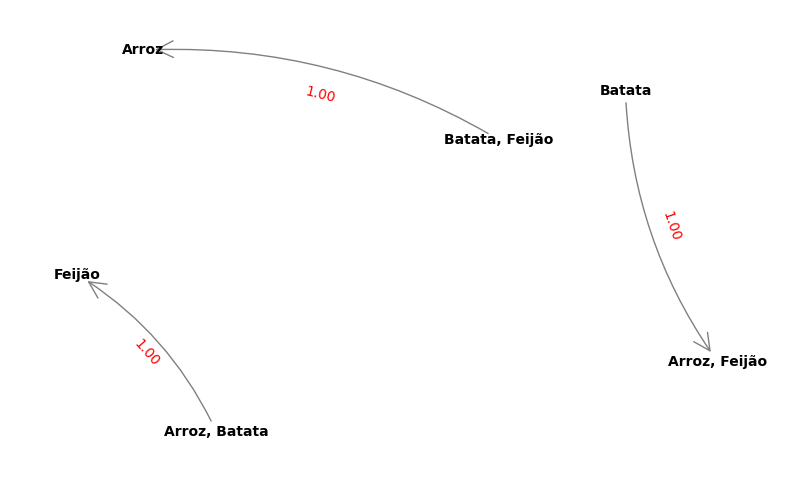

**Figura 2.14:** Grafo de associação: setas indicam a direção da regra e valores representam a confiança (conf_min=0.9).


In [68]:
from collections import defaultdict
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt

# 1. Funções de Cálculo
def calcular_suporte(itemset, transacoes):
    # Converte para frozenset se não for um conjunto (suporta listas, tuplas ou itens únicos)
    if not isinstance(itemset, (frozenset, set)):
        itemset = frozenset(itemset) if isinstance(itemset, (list, tuple)) else frozenset([itemset])
        
    contagem = sum(1 for t in transacoes if itemset.issubset(t))
    return contagem / len(transacoes)

def calcular_confianca(antecedente: frozenset, consequente: frozenset, transacoes: list):
    sup_antec = calcular_suporte(antecedente, transacoes)
    if sup_antec == 0: return 0.0
    return calcular_suporte(antecedente | consequente, transacoes) / sup_antec

# 2. Configuração e Dados
sup_min, conf_min = 0.4, 0.9

transacoes_raw = [
    {"Arroz", "Feijão", "Óleo"},
    {"Queijo", "Vinho"},
    {"Arroz", "Feijão", "Batata", "Óleo"},
    {"Arroz", "Água", "Queijo", "Vinho"},
    {"Arroz", "Feijão", "Batata", "Óleo"},
]
transacoes = [frozenset(t) for t in transacoes_raw]
print(f"Total de transações convertidas: {len(transacoes)}")

# USO DO DEFAULTDICT: Contagem de suporte individual
contagem_absoluta = defaultdict(int)
for t in transacoes:
    for item in t:
        contagem_absoluta[item] += 1
print("Contagem de suporte individual (L1):\n",dict(contagem_absoluta))

# Exemplo de uso: filtrando apenas itens que atendem ao suporte mínimo
itens_frequentes_l1 = {item for item, count in contagem_absoluta.items() 
                       if (count / len(transacoes)) >= sup_min}

print(f"Itens que passaram na poda de suporte (L1): {itens_frequentes_l1}\n")

# 3. Análise de Regras e Grafo
itemset_cf = frozenset(["Arroz", "Feijão", "Batata"])

itens_lista = sorted(list(itemset_cf))
G = nx.DiGraph()

# CABEÇALHO CORRIGIDO: Alinhado com a largura das colunas de dados
print(f"{'Regra (S -> CF-S)':<47} {'Conf.':>10} {'Status':>12}")
print("-" * 72)

for r in range(1, len(itens_lista)):
    for combo in combinations(itens_lista, r):
        S = frozenset(combo)
        consequente = itemset_cf - S
        conf = calcular_confianca(S, consequente, transacoes)
        
        # Formatação das strings para o print e para o grafo
        antec_str = str(sorted(list(S)))
        conseq_str = str(sorted(list(consequente)))
        label_regra = f"{antec_str:<22} -> {conseq_str:<20}"
        
        if conf >= conf_min:
            status = "ACEITA ✅"
            G.add_edge(", ".join(sorted(S)), ", ".join(sorted(consequente)), weight=conf)
        else:
            status = "REJEITADA ❌"
        
        print(f"{label_regra} {conf:>10.2f} {status:>12}")

# 4. Visualização Minimalista (Sem discos, foco em setas e nomes)
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, k=1.5, seed=42)

nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=30, edge_color='gray', 
                       connectionstyle="arc3,rad=0.15") 

labels_pesos = {k: f"{v:.2f}" for k, v in nx.get_edge_attributes(G, 'weight').items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels_pesos, font_color='red')

plt.axis('off')
plt.show()

A implementação apresentada automatiza a Etapa 2 do algoritmo Apriori, transformando um **conjunto frequente previamente identificado** (`itemset_cf`) em regras de associação candidatas. O código utiliza **Generators** para calcular o suporte de forma eficiente em termos de memória e um **defaultdict** para organizar a contagem inicial dos itens (**L1**). Ao calcular a confiança para cada combinação gerada pela função **combinations**, o sistema aplica uma poda baseada no limiar `conf_min`. As regras sobreviventes são apresentadas na [Figura 2.14](#fig-2-grafo-analise), onde a ausência de vértices circulares destaca os itens, e as setas indicam o fluxo lógico (SE $\to$ ENTÃO). Os valores em vermelho sobre as arestas representam a confiança, confirmando a precisão estatística de cada associação descoberta no dataset. Essa abordagem demonstra como as regras são derivadas a partir de um conjunto de itens que já superou o limiar de suporte (conjunto frequente), garantindo que a análise de confiança foque apenas em relações estatisticamente relevantes, otimizando o processo de descoberta de conhecimento.

### 🔹 Prática 4 — Algoritmo Apriori Simplificado

O algoritmo **Apriori** (AGRAWAL et al., 1993) é o mais clássico para mineração de regras de associação. Sua ideia central é a **propriedade anti-monotônica do suporte**: se um itemset tem suporte menor que o mínimo, nenhum de seus superconjuntos pode ter suporte maior. Isso permite podar o espaço de busca exponencialmente.

> ### 💡 Novos conceitos Python para Estruturação de Dados
>
> Para evoluir a implementação dos algoritmos de Mineração de Dados, o Python moderno oferece estruturas que tornam o código mais legível e eficiente:
>
> * **`dataclass` e `__post_init__`**: Além de gerar o construtor automaticamente, usamos o método `__post_init__` para calcular métricas derivadas (como o **Lift**) no momento em que a regra é criada, garantindo integridade aos dados.
> * **`itertools.combinations`**: Em vez de gerir laços manuais complexos, utilizamos esta função para gerar candidatos a conjuntos frequentes de forma exaustiva e otimizada, sendo o motor da Etapa 1 do Apriori.
> * **Tipagem Estática (`typing`)**: O uso de anotações como `list[frozenset]` ajuda na legibilidade e permite que ferramentas de análise identifiquem erros antes da execução, algo vital em projetos de Ciência de Dados.

RELATÓRIO DE MINERAÇÃO APRIORI (sup_min=0.4, conf_min=0.6)

1. Itemsets Frequentes Descobertos (18):
   - ['Arroz']                                sup=0.80
   - ['Batata']                               sup=0.40
   - ['Feijão']                               sup=0.60
   - ['Queijo']                               sup=0.40
   - ['Vinho']                                sup=0.40
   - ['Óleo']                                 sup=0.60
   - ['Arroz', 'Óleo']                        sup=0.60
   - ['Arroz', 'Batata']                      sup=0.40
   - ['Queijo', 'Vinho']                      sup=0.40
   - ['Feijão', 'Óleo']                       sup=0.60
   - ['Batata', 'Óleo']                       sup=0.40
   - ['Arroz', 'Feijão']                      sup=0.60
   - ['Batata', 'Feijão']                     sup=0.40
   - ['Arroz', 'Batata', 'Feijão']            sup=0.40
   - ['Batata', 'Feijão', 'Óleo']             sup=0.40
   - ['Arroz', 'Feijão', 'Óleo']              sup=0.60
   - ['Arroz', 'Bat

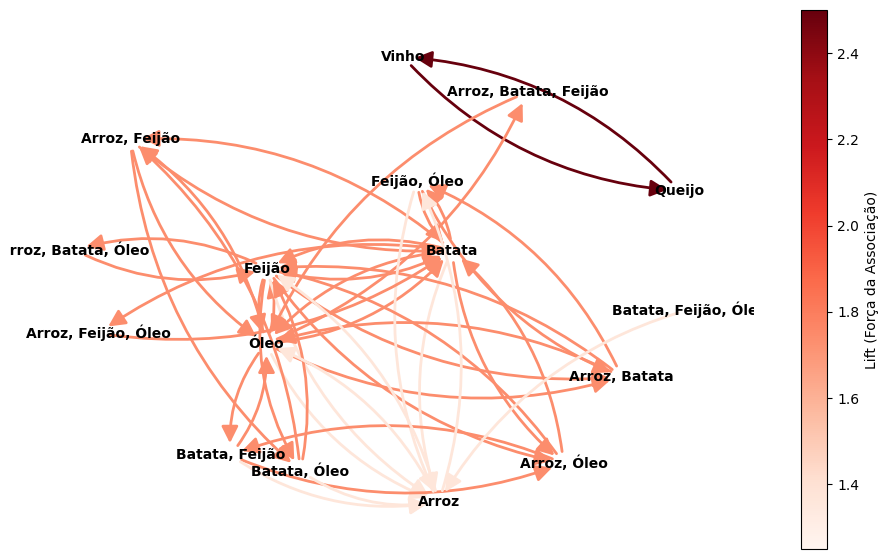

**Figura 15:** Análise completa: Relatório de regras e representação visual via Grafo de Lift.


In [65]:
from dataclasses import dataclass, field
from itertools import combinations
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt

# --- Funções de Cálculo (Baseadas na Prática 3) ---
def calcular_suporte(itemset, transacoes):
    # Converte para frozenset se não for um conjunto (suporta listas, tuplas ou itens únicos)
    if not isinstance(itemset, (frozenset, set)):
        itemset = frozenset(itemset) if isinstance(itemset, (list, tuple)) else frozenset([itemset])
        
    contagem = sum(1 for t in transacoes if itemset.issubset(t))
    return contagem / len(transacoes)

def calcular_confianca(antecedente, consequente, transacoes):
    sup_ant = calcular_suporte(antecedente, transacoes)
    sup_cons = calcular_suporte(antecedente | consequente, transacoes)
    return sup_cons / sup_ant if sup_ant > 0 else 0.0

@dataclass
class RegraAssociacao:
    """Estrutura moderna para armazenamento e cálculo de métricas."""
    antecedente: frozenset
    consequente: frozenset
    suporte: float
    confianca: float
    lift: float

    def __post_init__(self):
        # O Lift é calculado automaticamente na criação do objeto
        sup_cons = calcular_suporte(self.consequente, transacoes)
        self.lift = self.confianca / sup_cons if sup_cons > 0 else 0.0

    def __str__(self):
        ant = ", ".join(sorted(self.antecedente))
        con = ", ".join(sorted(self.consequente))
        return f"  {ant:<20} → {con:<20} \
            [sup={self.suporte:.2f}, conf={self.confianca:.2f}, lift={self.lift:.2f}]"

def apriori(transacoes, sup_min=0.4, conf_min=0.6):
    itens = sorted(set().union(*transacoes))
    frequentes = []
    candidatos_k = [frozenset([i]) for i in itens]

    # Etapa 1: Itemsets Frequentes (Poda de Suporte)
    while candidatos_k:
        freq_k = [c for c in candidatos_k if calcular_suporte(c, transacoes) >= sup_min]
        frequentes.extend(freq_k)
        if not freq_k: break
        k = len(freq_k[0]) + 1
        candidatos_k = list(set(a | b for a, b in combinations(freq_k, 2) if len(a | b) == k))

    # Etapa 2: Geração de Regras (Poda de Confiança)
    regras = []
    for itemset in frequentes:
        if len(itemset) < 2: continue
        for tam_ant in range(1, len(itemset)):
            for ant_tuple in combinations(itemset, tam_ant):
                ant = frozenset(ant_tuple)
                con = itemset - ant
                conf = calcular_confianca(ant, con, transacoes)
                if conf >= conf_min:
                    cal_sup = calcular_suporte(itemset, transacoes)
                    sup_consequente = calcular_suporte(con, transacoes)
                    lift = conf / sup_consequente if sup_consequente > 0 else 0.0
                    regras.append(RegraAssociacao(ant, con, cal_sup, conf, lift))
    
    return frequentes, sorted(regras, key=lambda r: r.lift, reverse=True)

# --- Configuração e Execução ---
transacoes = [frozenset({"Arroz", "Feijão", "Óleo"}), 
              frozenset({"Queijo", "Vinho"}), 
              frozenset({"Arroz", "Feijão", "Batata", "Óleo"}), 
              frozenset({"Arroz", "Água", "Vinho", "Queijo"}), 
              frozenset({"Arroz", "Feijão", "Batata", "Óleo"})]

freqs, regras_encontradas = apriori(transacoes)

# --- RELATÓRIO ORIGINAL ---
print("=" * 75)
print(f"RELATÓRIO DE MINERAÇÃO APRIORI (sup_min=0.4, conf_min=0.6)")
print("=" * 75)

print(f"\n1. Itemsets Frequentes Descobertos ({len(freqs)}):")
for f in sorted(freqs, key=len):
    print(f"   - {str(sorted(list(f))):<40} sup={calcular_suporte(f, transacoes):.2f}")

print(f"\n2. Regras de Associação (Ordenadas por Lift) ({len(regras_encontradas)}):")
for r in regras_encontradas:
    print(r)

# --- VISUALIZAÇÃO DO GRAFO ---
G = nx.DiGraph()
for r in regras_encontradas:
    G.add_edge(", ".join(sorted(r.antecedente)),", ".join(sorted(r.consequente)),weight=r.lift)

if G.edges():
    plt.figure(figsize=(12, 7))
    pos = nx.spring_layout(G, k=2.5, seed=42)
    lifts = [G[u][v]['weight'] for u, v in G.edges()]
    
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    v_min = min(lifts) * 0.9 if len(lifts) > 0 else 0
    v_max = max(lifts) if len(lifts) > 0 else 1
    nx.draw_networkx_edges(G, pos, edge_color=lifts, edge_cmap=plt.cm.Reds, 
                           width=2, arrowsize=25, connectionstyle="arc3,rad=0.2",
                           edge_vmin=v_min, edge_vmax=v_max)
    
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds, \
                               norm=plt.Normalize(vmin=min(lifts), vmax=max(lifts)))
    plt.colorbar(sm, ax=plt.gca(), label='Lift (Força da Associação)')
    plt.axis('off')
    plt.show()

O objetivo central deste código é automatizar a descoberta de conhecimento em grandes bases de dados, indo além da simples contagem de frequência. Enquanto o suporte e a confiança filtram regras matematicamente válidas, o foco no **Lift** busca extrair a relevância prática da associação.

Estatisticamente, se o suporte do consequente é muito alto (ex: quase todos os clientes compram "Pão"), uma regra como "Se comprar Queijo, então compra Pão" terá uma confiança elevada, mas pode ser enganosa, pois a compra do Pão ocorreria independentemente da presença do Queijo. O cálculo do Lift resolve esse viés ao medir a dependência entre os itens.

Na [Figura 15](#fig-apriori-final), a visualização busca reduzir a carga cognitiva do analista. Em vez de percorrer tabelas extensas, o grafo utiliza a intensidade da cor vermelha para destacar imediatamente as regras onde o Lift é mais expressivo. O layout expandido e a ausência de formas geométricas nos vértices garantem que os rótulos dos itens sejam os protagonistas, permitindo identificar padrões complexos de consumo com um simples relance.

#### 🧮 Métricas de Qualidade: Suporte, Confiança e Lift

Para que uma regra de associação seja considerada relevante, ela deve superar limiares de frequência e assertividade. A implementação no código utiliza três métricas fundamentais:

1. **Suporte ($\mathbf{Sup}$):** Indica a popularidade global de um conjunto de itens na base de dados.

$$\mathbf{Sup}(X \Rightarrow Y) = P(X \cup Y) = \frac{|X \cup Y|}{N}$$


2. **Confiança ($\mathbf{Conf}$):** Mede a probabilidade de encontrar o item $Y$ em transações que contêm $X$. Representa a precisão da regra.

$$\mathbf{Conf}(X \Rightarrow Y) = P(Y|X) = \frac{\mathbf{Sup}(X \cup Y)}{\mathbf{Sup}(X)}$$


3. **$\mathbf{Lift}$ (Elevação):** Controla o viés de itens muito frequentes, medindo o aumento na probabilidade de compra de $Y$ dado que $X$ foi adquirido, em relação à compra de $Y$ ao acaso.

$$\mathbf{Lift}(X \Rightarrow Y) = \frac{\mathbf{Conf}(X \Rightarrow Y)}{\mathbf{Sup}(Y)}$$



**Interpretação do $\mathbf{Lift}$:**

* **$\mathbf{Lift} > 1$:** O antecedente $X$ impulsiona a venda do consequente $Y$ (associação positiva).
* **$\mathbf{Lift} = 1$:** $X$ e $Y$ são independentes; a regra não possui poder preditivo real.
* **$\mathbf{Lift} < 1$:** A presença de $X$ inibe a presença de $Y$ (efeito de substituição).

### 🔹 Prática 5 — Simulação do Apriori Clássico (Join & Prune)

Nesta etapa, focamos na **Geração de Candidatos** eficiente, como descrito nas obras de Agrawal et al. (1993) e Han e Kamber (2008). O segredo da performance do Apriori reside em não testar todas as combinações matemáticas possíveis, mas apenas aquelas cujos subconjuntos já se provaram frequentes.

> ### 💡 Otimização por Prefixo e Poda (Pruning)
>
> O código abaixo implementa as duas regras de ouro de Agrawal et al. (1993) :
>
> 1. **Passo de Join**: Une dois conjuntos de tamanho $k-1$ apenas se eles compartilharem os mesmos primeiros $k-2$ itens (prefixo comum).
> 2. **Passo de Prune**: Aplica a propriedade anti-monotônica: se um candidato possui qualquer subconjunto que não seja frequente, ele é descartado antes da contagem do suporte.


In [66]:
from itertools import combinations
from collections import defaultdict

# 1. Funções de Apoio
def calcular_suporte(itemset, transacoes):
    # Converte para frozenset se não for um conjunto (suporta listas, tuplas ou itens únicos)
    if not isinstance(itemset, (frozenset, set)):
        itemset = frozenset(itemset) if isinstance(itemset, (list, tuple)) else frozenset([itemset])
        
    contagem = sum(1 for t in transacoes if itemset.issubset(t))
    return contagem / len(transacoes)

# 2. Lógica Join e Prune
def todos_subconjuntos_frequentes(candidato: frozenset, freq_k_minus_1: set, k: int):
    subconjuntos = [frozenset(c) for c in combinations(candidato, k-1)]
    return all(s in freq_k_minus_1 for s in subconjuntos)

def apriori_gen(freq_k_minus_1: list, k: int) -> list:
    candidatos = []
    lista_ordenada = sorted([sorted(list(i)) for i in freq_k_minus_1])
    
    n = len(lista_ordenada)
    for i in range(n):
        for j in range(i + 1, n):
            # O fatiamento [:k-2] funciona para qualquer k >= 2.
            # Se k=2, compara [] == [], o que é sempre True (Join de 1-itemsets).
            if lista_ordenada[i][:k-2] == lista_ordenada[j][:k-2]:
                novo_candidato = frozenset(lista_ordenada[i]) | frozenset(lista_ordenada[j])
                
                # IMPORTANTE: Passo de Prune (Poda)
                # Só aceita o candidato se todos os seus subconjuntos k-1 forem frequentes
                if todos_subconjuntos_frequentes(novo_candidato, freq_k_minus_1, k):
                    candidatos.append(novo_candidato)
    return list(set(candidatos))

# 3. Dados e Inicialização
transacoes = [
    frozenset({"Arroz", "Feijão", "Óleo"}),
    frozenset({"Queijo", "Vinho"}),
    frozenset({"Arroz", "Feijão", "Batata", "Óleo"}),
    frozenset({"Arroz", "Água", "Vinho", "Queijo"}),
    frozenset({"Arroz", "Feijão", "Batata", "Óleo"}),
]
sup_min = 0.4

# Geração do L1
contagem_individual = defaultdict(int)
for t in transacoes:
    for item in t:
        contagem_individual[frozenset([item])] += 1

# Para: (Transformar em set para busca O(1) na poda)
L1 = {item for item, count in contagem_individual.items() if (count/len(transacoes)) >= sup_min}

# 4. Simulação do Fluxo
print(f"L1 (Frequentes): {[sorted(list(x)) for x in sorted(L1)]}\n")

C2 = apriori_gen(L1, 2)
L2 = [c for c in C2 if calcular_suporte(c, transacoes) >= sup_min]
print(f"L2 (Frequentes tamanho 2): {len(L2)}")
for l in sorted([sorted(list(x)) for x in L2]): print(f"  {l}")

C3 = apriori_gen(L2, 3)
print(f"\nC3 (Candidatos tamanho 3) gerados após PRUNAÇÃO: {len(C3)}")
# Iterar diretamente sobre os frozensets para manter o tipo correto no cálculo
for c in sorted(C3):
    sup = calcular_suporte(c, transacoes)
    print(f"  {sorted(list(c))} -> suporte: {sup:.2f}")

L1 (Frequentes): [['Óleo'], ['Batata'], ['Vinho'], ['Queijo'], ['Arroz'], ['Feijão']]

L2 (Frequentes tamanho 2): 7
  ['Arroz', 'Batata']
  ['Arroz', 'Feijão']
  ['Arroz', 'Óleo']
  ['Batata', 'Feijão']
  ['Batata', 'Óleo']
  ['Feijão', 'Óleo']
  ['Queijo', 'Vinho']

C3 (Candidatos tamanho 3) gerados após PRUNAÇÃO: 4
  ['Batata', 'Feijão', 'Óleo'] -> suporte: 0.40
  ['Arroz', 'Feijão', 'Óleo'] -> suporte: 0.60
  ['Arroz', 'Batata', 'Feijão'] -> suporte: 0.40
  ['Arroz', 'Batata', 'Óleo'] -> suporte: 0.40


#### Explicação Conceitual do Fluxo Clássico:

* **Geração de Candidatos ($C_k$):** Em vez de usar `combinations(todos_itens, k)`, o que seria proibitivo em bases grandes, o Apriori usa apenas os conjuntos que já provaram ser frequentes no nível anterior ($L_{k-1}$).
* **Poda (Pruning):** Se um candidato a conjunto de 3 itens (ex: `{Arroz, Feijão, Batata}`) for gerado, mas o subconjunto `{Feijão, Batata}` não estiver na lista de frequentes anterior, o candidato é descartado imediatamente, antes mesmo de olharmos para a base de dados. Isso economiza processamento computacional massivo.
* **Eficiência:** Essa abordagem reduz drasticamente o número de acessos ao disco/memória para contar o suporte, focando apenas no que é estatisticamente promissor.

Note que a ordenação alfabética dos itens nos conjuntos permite que o passo de Join encontre pares compatíveis de forma sistemática.

#### Mapa de Associações (Visualização Final)

Após a geração de candidatos e validação das regras, o conhecimento extraído pode ser mapeado em um grafo de adjacência. Na [Figura 16](#fig-mapa-associacoes), utilizamos a **Confiança** como peso das conexões para identificar os "núcleos" de consumo.


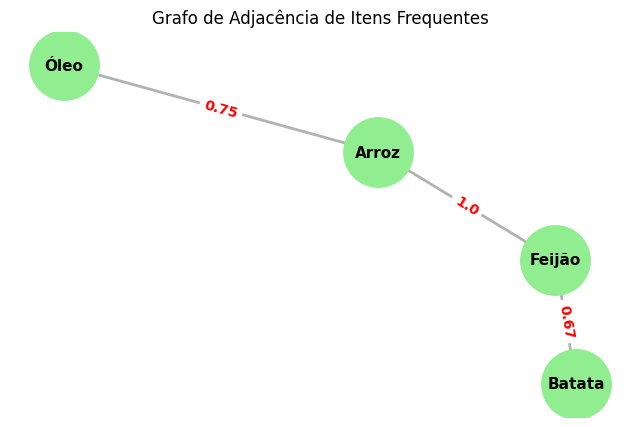

**Figura 16:** Mapa de Associações: Conexões entre itens baseadas na confiança das regras.


In [67]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.Graph()
# Dados extraídos da simulação acima (Tabela 2.13 do material teórico)
conexoes = [
    ("Arroz", "Feijão", 1.0), 
    ("Feijão", "Batata", 0.67), 
    ("Arroz", "Óleo", 0.75)
]

for item1, item2, peso in conexoes:
    G.add_edge(item1, item2, weight=peso)

plt.figure(figsize=(8, 5))
pos = nx.spring_layout(G, seed=42, k=1.2) 

# Estética: Verde para os nós (referência institucional) e labels destacados
nx.draw_networkx_nodes(G, pos, node_color='lightgreen', node_size=2500)
nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray', alpha=0.6)

# Exibe os pesos (Confiança) em vermelho
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, \
                             font_color='red', font_weight='bold')

plt.title("Grafo de Adjacência de Itens Frequentes")
plt.axis('off')
plt.show()

**Conclusão da Atividade:**

Através destas práticas, observamos que a Mineração de Regras de Associação não é apenas uma busca exaustiva por combinações. O algoritmo **Apriori** demonstra como a **Propriedade Anti-monotônica** (Poda) permite reduzir drasticamente o esforço computacional. Além disso, a visualização por meio de grafos de **Lift** permite que o analista ignore associações óbvias (como pão e manteiga) e foque em padrões que realmente agregam valor ao negócio.

## 🤖 Uso do NotebookLM como Tutor Complementar

Seguindo o padrão do capítulo anterior, além dos notebooks interativos no Google Colab, incentiva-se o uso do **NotebookLM** como ferramenta complementar de aprendizagem. Essa ferramenta de IA utiliza exclusivamente os documentos fornecidos pelos autores como base de conhecimento, garantindo respostas alinhadas ao conteúdo do livro.

Para cada capítulo, foi preparado um projeto específico na plataforma. Para uma experiência de estudo ampliada, utilize o acesso abaixo:

> ### ❗ 🎓 Estude com o Tutor Inteligente
>
> Para interagir com o conteúdo deste capítulo, acesse o link abaixo. O ambiente contém materiais didáticos em diferentes formatos, gerados a partir do **PDF** do capítulo. Na plataforma, explore especialmente as opções **Guia de Estudo** e **Conversa** para aprofundar sua compreensão.
>
> [🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 02](https://notebooklm.google.com/notebook/421763f5-e597-4ec9-99da-6e0b5ca3e9bb)


## Considerações Finais

Um conjunto de Regras de Associação constitui uma forma de conhecimento
extraído de uma Base de Dados, sendo esta representação do conhecimento
geralmente um tipo de aprendizado muito útil para aplicações práticas,
como o aumento de vendas de uma rede de supermercados, o projeto de
catálogos de novos produtos ou o lançamento de campanhas promocionais
baseadas em vendas casadas. Geralmente quando fazemos busca na Web, ao
digitarmos uma palavra de busca é comum que outras palavras sejam
sugeridas. Isso ocorre porque a ferramenta de busca está usando Regras
de Associação e tem em sua Base de Dados registros de que pessoas que
buscam a Palavra_1 geralmente buscam também a `Palavra_2`, a `Palavra_3`, e
assim por diante.

Nesta primeira abordagem da extração de conhecimento a partir de uma
Base de Dados foi suficiente apenas um procedimento algoritmo, sem
necessidade de inferências. Nos próximos capítulos vamos mostrar que na
prática é comum nos depararmos com situações para as quais não se
conhece um algoritmo que produza o conhecimento necessário para uma
tomada de decisão. Para estes casos, será necessário pensar num
mecanismo de inferência que nos permita chegar à conclusão mais
plausível para determinada situação. Esse é o caso de sistemas
conhecidos como Sistemas Especialistas, que auxiliam por exemplo um
médico a fazer diagnóstico a partir dos sintomas do paciente. Como nem
sempre os sintomas declarados pelo paciente são compatíveis com
determinada doença, ou então porque o paciente omite determinados
sintomas importantes para o diagnóstico correto, o sistema precisa fazer
inferências comparando sua Base \[permanente\] de Conhecimento com os
sintomas declarados.

Regras de Associação frequentemente usam atributos nominais (por exemplo,
temperatura elevada, amena, baixa) e mais raramente atributos numéricos
(por exemplo $40^\circ\mathrm{C},\; 23^\circ\mathrm{C},\; 4^\circ\mathrm{C}$), porque algoritmos para
extração de Regras de Associação com atributos numéricos não costumam
apresentar bom desempenho em grandes Bases de Dados. Além disso, ao não
levar em conta por exemplo o preço de um artigo ou a quantidade de itens
vendidos em cada transação, as Regras de Associação geralmente se
transformam numa forma simplista de representação do conhecimento
extraído da Base de Dados.

No exemplo da Cesta de Artigos mostramos como gerar Regras de Associação
que indiquem venda casada dos artigos mais comum. Mas, frequentemente,
os especialistas em vendas não estão muito interessados nestes itens
porque a associação entre eles já é conhecida. Na realidade, estes
especialistas buscam pares de itens dos quais um deles é um produto
barato e o outro tem alta taxa de lucro. Nestes casos, lançar uma
superpromoção do produto barato faz com que as vendas do produto com
alta taxa de lucro aumente.

Em nossa Cesta de Artigos está implícito o padrão de associação entre
Queijo e Vinho. Talvez aí, numa campanha de inverno, cadeias de
supermercados possam fazer promoções de queijos com o único propósito de
vender mais vinhos. Mas como as vendas de ambos eram relativamente
baixas, esta regra não satisfez os critérios estabelecidos de
$\mathbf{SupMin}$ e $\mathbf{ConfMin}$. E, no entanto, é possivelmente este tipo
de informação a mais procurada. O que fazer para conseguir minerar as
pérolas de informação?

## Lista de Exercícios

1. (20%) Explique com suas próprias palavras a importância do **Suporte
Mínimo ($\mathbf{SupMin}$)** e **Confiança Mínima (ConfMin)** para a geração de
**Regras de Associação**.

2. (30%) Explique com suas próprias palavras o que é **Conjunto
Frequente** no contexto das **Regras de Associação**.

3. (50%) Crie uma pequena **Cesta de Compras** (± 5 Exemplos) com itens
relacionados ao seu ambiente de trabalho, ou à área de seu TCC, ou a
qualquer outra área de seu interesse, e gere as **Regras de Associação**
no Weka. Anexe o respectivo arquivo "`.arff`", e um pequeno relatório
sobre a simulação.

---

### 🔧 Desafios de Programação (extras)

4. **(Médio)** Adicione a métrica **Lift** à função `apriori()` da
   Prática 4 como critério de filtragem (parâmetro `lift_min`).

5. **(Avançado)** Pesquise o algoritmo **FP-Growth** como alternativa
   mais eficiente ao Apriori. Quais são as principais vantagens em
   bases de dados muito grandes?


## Referências do Capítulo


Este capítulo baseou-se nas obras fundamentais que consolidaram as bases da mineração de dados: Agrawal et al. (1993), para a introdução histórica e formal das regras de associação; Frank et al. (2016), como documentação técnica e referência do sistema WEKA; Rocha et al. (2008), Tan et al. (2009) e Witten e Frank (2005), para os conceitos estruturais do processo de descoberta de conhecimento (KDD) e algoritmos de mineração; Padhy (2010), para a integração com sistemas inteligentes; e o trabalho clássico de Quinlan (1986), sobre a indução de árvores de decisão.

AGRAWAL, Rakesh; IMIELIŃSKI, Tomasz; SWAMI, Arun. **Mining association rules between sets of items in large databases**. 1993.

FRANK, Eibe; HALL, Mark A.; WITTEN, Ian H. **The {WEKA} Workbench. Online Appendix for "Data Mining: Practical Machine Learning Tools and Techniques"**. Morgan Kaufmann, 2016.

HAN, J.; KAMBER, M. **Data Mining: Concepts and Techniques**. Morgan Kaufmann Publishers, 2008.

PADHY, N. P. **Artificial Intelligence and Intelligent Systems**. Oxford University Press, 2010.

QUINLAN, R. **Induction of Decision Trees**. 1986.

ROCHA, Miguel; CORTEZ, Paulo; NEVES, Jos{\'e} M. **Sem titulo**. Lisboa, Editora de Inform{\'a}tica, 2008.

TAN, P.N.; STEINBACH, M.; KUMAR, V. **Introdução ao Data Mining Mineração de Dados**. Editora Ciência Moderna Ltda., 2009.

WITTEN, I. H.; FRANK, E. **Data Mining: Practical Machine Learning Tools and Techniques**. Morgan Kaufmann Publishers, 2005.